In [1]:
! pip install langchain langgraph langchain-groq python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 13.0 MB/s eta 0:00:00


# Simple Sequential Workflow
-- BMI Calculator --

In [23]:
# libraries
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from IPython.display import Image
from typing import TypedDict

In [26]:
# define state
class BmiState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [25]:
# BMI function
def calculateBMI(state: BmiState) -> BmiState:
    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height ** 2)
    state["bmi"] = round(bmi, 2)

    return state

In [38]:
# Fit function
def calculateCategory(state: BmiState) -> BmiState:
    bmi = state["bmi"]

    if bmi < 18.5:
        state["category"] = "underweight"
    elif 18.5 <= bmi <= 25:
        state["category"] = "normal"
    elif 25 <= bmi <= 30:
        state["category"] = "overweight"
    else:
        state["category"] = "obese"

    return state

In [39]:
# define graph
graph = StateGraph(BmiState)

# define nodes
graph.add_node("calculate_bmi", calculateBMI)
graph.add_node("calculate_category", calculateCategory)

# define edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "calculate_category")
graph.add_edge("calculate_category", END)

# compile
workflow = graph.compile()

In [40]:
# execute graph
initial_state = {"weight_kg": 80, "height_m": 1.73}
final_state = workflow.invoke(initial_state)
final_state

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'overweight'}

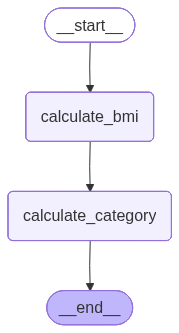

In [41]:
# check graph
Image(workflow.get_graph().draw_mermaid_png())